# Lab: K-Nearest Neighbors Classifier



## Objectives

After completing this lab you will be able to:

*   Use K-Nearest neighbors to classify data
*   Apply KNN classifier on a real world data set 

Imagine a telecommunications provider has segmented its customer base by service usage patterns, categorizing the customers into four groups. If demographic data can be used to predict group membership, the company can customize offers for individual prospective customers. It is a classification problem. That is, given the dataset,  with predefined labels, we need to build a model to be used to predict class of a new or unknown case.

The example focuses on using demographic data, such as region, age, and marital, to predict usage patterns.

The target field, called **custcat**, has four possible service categories that correspond to the four customer groups, as follows:

1. Basic Service
2. E-Service
3. Plus Service
4. Total Service

Our objective is to build a classifier to predict the service category for unknown cases. We will use a specific type of classification called K-nearest neighbors.


In [2]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests


In [2]:
def download (url, fileName):
    response = requests.get(url)
    if(response.status_code == 200):
        with open(fileName, "wb") as f:
            f.write(response.content)

In [4]:
path = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/teleCust1000t.csv'
file_name =  "teleCust1000t.csv"

In [4]:
download(path, file_name)

In [6]:
df = pd.read_csv(file_name)
df.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3


## Data Preprocessing

In [7]:
# check null values
df.isnull().sum()

region     0
tenure     0
age        0
marital    0
address    0
income     0
ed         0
employ     0
retire     0
gender     0
reside     0
custcat    0
dtype: int64

### Data Visualization and Analysis

Let us first look at the class-wise distribution of the data set.




In [8]:
df['custcat'].value_counts()

custcat
3    281
1    266
4    236
2    217
Name: count, dtype: int64

Hence, we can say that we have records of 281 customers who opt for Plus Services, 266 for Basic-services, 236 for Total Services, and 217 for E-Services. It can thus be seen that the data set is mostly balanced between the different classes and requires no special means of accounting for class bias.


We can also visualize the correlation map of the data set to determine how the different features are related to each other. 


<Axes: >

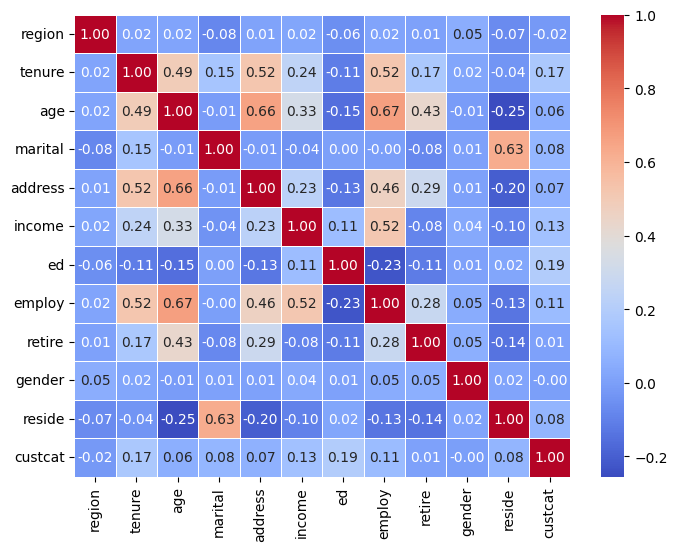

In [9]:
# check the correlation among features
corr_values = df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_values, cmap='coolwarm', annot=True,fmt='.2f', linewidths=0.5)

As is visible from the correlation map, some features have beeter correlation among them than others, basically indicating the depth of relationship between the two features. What is of interest to us is the correlation of the target feature, i.e. `custcat` with all the other features. This will help us identify which features should be focussed on for modeling and which ones can be ignored. 

The following code snippet will give us a list of features sorted in the descending order of their absolute correlation values with respect to the target field.


In [10]:
# filter and get the maxium features which have highest correlation
corr_matrix = df.corr()['custcat'].drop('custcat')
corr_matrix = corr_matrix.sort_values(ascending=False)
corr_matrix

ed         0.193864
tenure     0.166691
income     0.134525
employ     0.110011
marital    0.083836
reside     0.082022
address    0.067913
age        0.056909
retire     0.008908
gender    -0.004966
region    -0.023771
Name: custcat, dtype: float64

### Separate the input and target features


In [11]:
x_data = df.drop('custcat',axis =1)
y_data = df['custcat']

print("x data set:\n", x_data.head())
print("\ny data set:\n", y_data.head())


x data set:
    region  tenure  age  marital  address  ...  ed  employ  retire  gender  reside
0       2      13   44        1        9  ...   4       5     0.0       0       2
1       3      11   33        1        7  ...   5       5     0.0       0       6
2       3      68   52        1       24  ...   1      29     0.0       1       2
3       2      33   33        0       12  ...   2       0     0.0       1       1
4       2      23   30        1        9  ...   1       2     0.0       0       4

[5 rows x 11 columns]

y data set:
 0    1
1    4
2    3
3    1
4    3
Name: custcat, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=4)

In [13]:
# data standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scale = scaler.fit_transform(x_train)
x_test_scale = scaler.transform(x_test)
 

## KNN Classification


### Training
Initially, you may start by using a small value as the value of k, say k = 4.


In [29]:
from sklearn.neighbors import KNeighborsClassifier 

k = 4
#train the model

knn_neighbour = KNeighborsClassifier(n_neighbors=k)
knn_neighbour.fit(x_train_scale, y_train)





,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Predicting
Once the model is trained, we can now use this model to generate predictions for the test set. 


In [30]:
y_pred = knn_neighbour.predict(x_test_scale)

In [ ]:
from sklearn.metrics import accuracy_score


# accuracy 
print("accuracy of the model: ", 100*accuracy_score(y_test, y_pred),"%")

accuracy of the model:  32.0 %


### Choosing the correct value of k

K in KNN, is the number of nearest neighbors to examine. However, the choice of the value of 'k' clearly affects the model. Therefore, the appropriate choice of the value of the variable `k` becomes an important task. The general way of doing this is to train the model on a set of different values of k and noting the performance of the trained model on the testing set. The model with the best value of `accuracy_score` is the one with the ideal value of the parameter k.

Check the performance of the model for 10 values of k, ranging from 1-9. You can evaluate the accuracy along with the standard deviation of the accuracy as well to get a holistic picture of the model performance.


In [58]:
ks = 38
acc = np.zeros(ks)
std = np.zeros(ks)

for i in range(1,(ks+1)):
    knn_mode_new = KNeighborsClassifier(n_neighbors=i)
    knn_mode_new.fit(x_train_scale, y_train)
    y_pred_new = knn_mode_new.predict(x_test_scale)
    accuracy = accuracy_score(y_test, y_pred_new)
    acc[i-1] = accuracy
    std[i-1] = np.std(y_test == y_pred_new)/np.sqrt(y_pred_new.shape[0])
    
    print("accuracy of the model: ", 100*acc[i-1],"%")
    print("Standard error of the model: ", 100*std[i-1],"%")

accuracy of the model:  30.0 %
Standard error of the model:  3.2403703492039297 %
accuracy of the model:  30.5 %
Standard error of the model:  3.2555721463361857 %
accuracy of the model:  31.5 %
Standard error of the model:  3.2846232660687287 %
accuracy of the model:  32.0 %
Standard error of the model:  3.298484500494128 %
accuracy of the model:  31.5 %
Standard error of the model:  3.2846232660687287 %
accuracy of the model:  31.0 %
Standard error of the model:  3.270321085153566 %
accuracy of the model:  33.0 %
Standard error of the model:  3.32490601370926 %
accuracy of the model:  32.5 %
Standard error of the model:  3.3119103248729425 %
accuracy of the model:  33.5 %
Standard error of the model:  3.3374765916782096 %
accuracy of the model:  35.5 %
Standard error of the model:  3.3836001536824645 %
accuracy of the model:  33.5 %
Standard error of the model:  3.3374765916782096 %
accuracy of the model:  35.0 %
Standard error of the model:  3.3726843908080104 %
accuracy of the mode

### Plot the model accuracy for a different number of neighbors.
Now, you can plot the model accuracy and the standard deviation to identify the model with the most suited value of k.


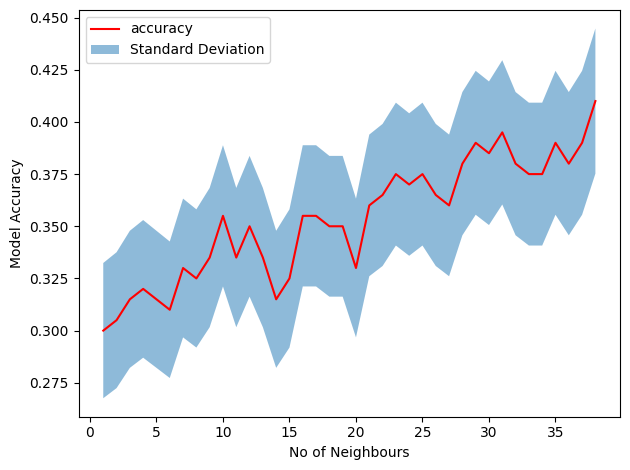

In [59]:
plt.plot(range(1,ks+1), acc,'r')
plt.fill_between(range(1,1+ks), acc-1*std,acc+1*std,alpha = 0.5)
plt.legend(("accuracy","Standard Deviation"))
plt.ylabel("Model Accuracy")
plt.xlabel("No of Neighbours")
plt.tight_layout()
plt.show()